# Step 0.1 — Initial inspection of the INbreast dataset

---

In this notebook we inspect the INbreast dataset.

Inbreast Summary:
- There are 410 DICOM files
- `INbreast.xls` contains the labels for each file 

`INbreast.xls` summary: 
- 410 rows - one for each DICOM file
- 108 rows with a mass

Kaggle mass annotations: 
- 343 XML files (one per annotated image; 67 images have no XML)
- 116  Mass ROIs - used in Step 1.2 mass extraction
- spread across 107 distinct files
- (99 files × 1 mass) + (7 × 2) + (1 × 3) = 116 total masses 

Razali numbers: 
 - paper has 112 masses 

## 1. Inspecting a single DICOM file and its metadata

The cell below:

1. Picks the first `.dcm` in the dataset directory.
2. Reads it with `pydicom`.
3. Clips the pixel values at the 1st and 99th percentiles and rescales to `[0, 1]`.
4. Dumps every DICOM tag in the file as a table.

**Why percentile clipping rather than a raw min-max stretch?** The reference paper converts DICOMs to PNG and then min-max normalises to `[0, 1]`. We tested that approach on these mammograms and found a small number of pixels (calibration markers, edge artefacts, sensor hot spots) sit far above the bulk distribution of breast tissue. A raw min-max stretch is set by those outliers and compresses the meaningful tissue values into a narrow band near zero, hurting visible contrast. A 1st/99th percentile clip prior to rescaling is robust to those extreme values and keeps the breast-tissue dynamic range well-spread across `[0, 1]`. An ablation in Step 1.1 (`norm_mode="minmax"`) confirms this numerically as well (~83% 10-fold CV accuracy with percentile clipping vs ~80% with raw min-max on the tissue task). 

File: ../data/raw/inbreast/ALL-IMGS/22427705_d713ef5849f98b6c_MG_L_CC_ANON.dcm


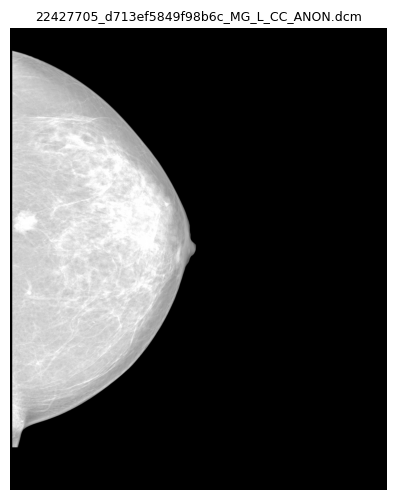

,tag,keyword,vr,name,value
0,"(0008,0016)",SOPClassUID,UI,SOP Class UID,1.2.840.10008.5.1.4.1.1.7
1,"(0008,0018)",SOPInstanceUID,UI,SOP Instance UID,1.3.6.1.4.1.9590.100.1.1.230418120812595497207...
2,"(0008,0020)",StudyDate,DA,Study Date,
3,"(0008,0023)",ContentDate,DA,Content Date,20111229
4,"(0008,0030)",StudyTime,TM,Study Time,
5,"(0008,0033)",ContentTime,TM,Content Time,220054.702995
6,"(0008,0050)",AccessionNumber,SH,Accession Number,
7,"(0008,0060)",Modality,CS,Modality,OT
8,"(0008,0064)",ConversionType,CS,Conversion Type,WSD
9,"(0008,0090)",ReferringPhysicianName,PN,Referring Physician's Name,


In [3]:
import pydicom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---- pick ONE file (edit this path if you want a specific one) ----
dicom_path = Path("../data/raw/inbreast/ALL-IMGS")
dicom_path = next(dicom_path.glob("*.dcm"))  # first .dcm found
print("File:", dicom_path)

# ---- read DICOM ----
ds = pydicom.dcmread(str(dicom_path))

# ---- image for viewing ----
img = ds.pixel_array.astype(np.float32)

# Robust normalisation to [0, 1] via 1st/99th-percentile clip.
# (Plain min-max scaling would be pulled by a handful of extreme edge
# pixels — see the markdown above.)
lo, hi = np.percentile(img, (1, 99))
img = np.clip(img, lo, hi)
img = (img - lo) / (hi - lo + 1e-8)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title(dicom_path.name, fontsize=9)
plt.axis("off")
plt.show()

# ---- ALL metadata as a table ----
rows = []
for elem in ds.iterall():
    tag = str(elem.tag)
    keyword = elem.keyword
    vr = elem.VR
    name = elem.name
    if keyword == "PixelData":
        try:
            value = f"<PixelData: {len(elem.value)} bytes>"
        except Exception:
            value = "<PixelData>"
    else:
        s = str(elem.value)
        if len(s) > 200:
            s = s[:200] + "..."
        value = s
    rows.append((tag, keyword, vr, name, value))

meta_df = pd.DataFrame(rows, columns=["tag", "keyword", "vr", "name", "value"])
display(meta_df)

### What the metadata tells us

Most of the tags in the table above are clinical-workstation administrivia — UIDs, manufacturer details, timestamps, study and series numbers. The fields that matter for this project are:

- `PhotometricInterpretation` — every INbreast file is `MONOCHROME2` (audited across all 410 DICOMs), so no inversion is required for this dataset. 
- `BitsStored` / `BitsAllocated` — tells me the dynamic range (16-bit container, ~12 bits actually used). Justifies the percentile-based normalisation I am using.
- `Rows` / `Columns` — image dimensions vary file-to-file. Preprocessing has to handle this.
- The pixel array itself, obviously.

Things that are *not* useful for the classification task:

- Patient identifiers (anonymised anyway).
- Acquisition device specifics.
- View and laterality — these are encoded in the *filename* rather than reliably in the DICOM tags, so Step 0.2 parses them from there instead.

The takeaway from this single-file inspection is: the per-file DICOM metadata adds little to what the filenames plus the external XLS and XML files already provide. The XLS carries BIRADS, ACR, view, laterality. The XML files carry lesion polygon annotations. The DICOM is just the pixel container.


### Min–max stretch vs percentile clip — visual comparison

The argument above is easier to see than to read. Below is the **same** mammogram normalised two ways: a plain min–max stretch (left) and the 1st/99th-percentile clip we adopt (right). A handful of bright outlier pixels set the top of the min–max range, pushing the breast tissue into a dark, low-contrast band; the percentile clip is robust to them and keeps the tissue spread across the display range.

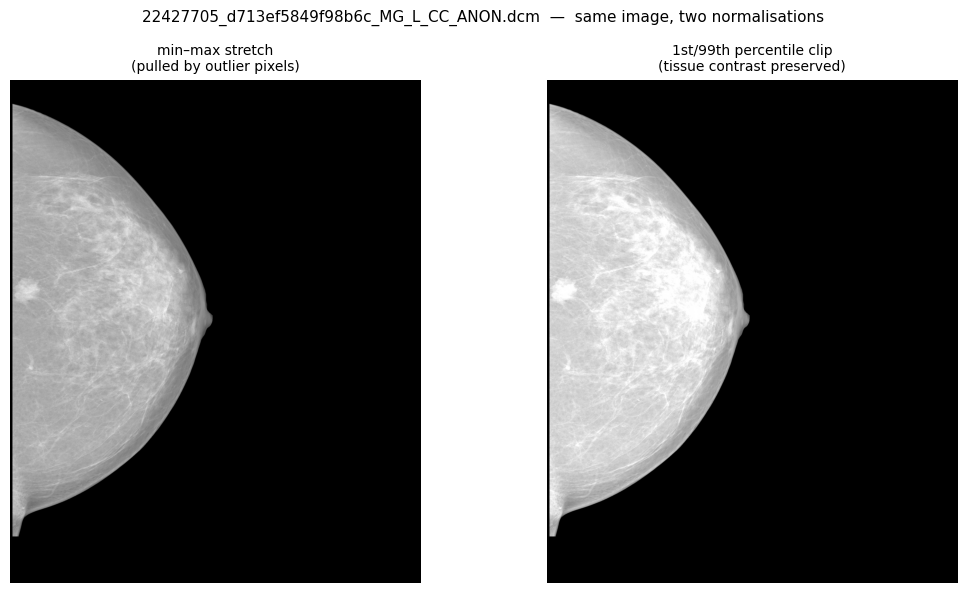

raw pixel range : [0, 2184]   1st/99th pctile : [0, 1772]
the top 1% of pixels occupy 412 of 2184 intensity levels (19% of the min–max range): a raw stretch spends that share of the display range on a handful of bright outliers, which is why tissue contrast collapses on the left.


In [4]:
# Same image under two normalisations — the visual justification for the percentile clip.
demo = next(Path("../data/raw/inbreast/ALL-IMGS").glob("*.dcm"))
raw = pydicom.dcmread(str(demo)).pixel_array.astype(np.float32)

# (a) plain min-max stretch (the paper's PNG-style recipe)
mm = (raw - raw.min()) / (raw.max() - raw.min() + 1e-8)

# (b) 1st/99th percentile clip, then rescale (ours)
lo, hi = np.percentile(raw, (1, 99))
pc = np.clip(raw, lo, hi)
pc = (pc - lo) / (hi - lo + 1e-8)

fig, ax = plt.subplots(1, 2, figsize=(11, 6))
ax[0].imshow(mm, cmap="gray", vmin=0, vmax=1)
ax[0].set_title("min–max stretch\n(pulled by outlier pixels)", fontsize=10); ax[0].axis("off")
ax[1].imshow(pc, cmap="gray", vmin=0, vmax=1)
ax[1].set_title("1st/99th percentile clip\n(tissue contrast preserved)", fontsize=10); ax[1].axis("off")
fig.suptitle(f"{demo.name}  —  same image, two normalisations", fontsize=11)
plt.tight_layout(); plt.show()

span = raw.max() - raw.min() + 1e-8
print(f"raw pixel range : [{raw.min():.0f}, {raw.max():.0f}]   1st/99th pctile : [{lo:.0f}, {hi:.0f}]")
print(f"the top 1% of pixels occupy {raw.max()-hi:.0f} of {span:.0f} intensity levels "
      f"({100*(raw.max()-hi)/span:.0f}% of the min–max range): a raw stretch spends that share of the "
      f"display range on a handful of bright outliers, which is why tissue contrast collapses on the left.")

## 2. Dataset-wide inventory and header audit

A single file (Section 1) cannot justify dataset-level claims. The cell below loops over **all** DICOMs and **all** XML annotations and derives every count quoted in the summary at the top of this notebook — number of images, XML files, Mass ROIs, mass-bearing images, and `INbreast.xls` mass-flagged rows — together with the DICOM header fields that justify the loader (photometric interpretation, VOI LUT presence, bit depth). It runs in a few seconds.

In [5]:
# === Section 2 — dataset-wide inventory + DICOM header audit ===
# Derives every count in the summary cell at the top, so the notebook
# itself is the evidence rather than an external one-off script.
from collections import Counter
import plistlib

IMG_DIR  = Path("../data/raw/inbreast/ALL-IMGS")
XML_DIR  = Path("../data/raw/kaggle_inbreast/AllXML")
XLS_PATH = Path("../data/raw/inbreast/INbreast.xls")

dcms = sorted(IMG_DIR.glob("*.dcm"))
xmls = sorted(XML_DIR.glob("*.xml"))

# --- DICOM header audit (justifies MONOCHROME2, no VOI LUT, 16-bit) ---
photo, bits = Counter(), Counter()
n_voilut = n_window = 0
for fp in dcms:
    ds = pydicom.dcmread(str(fp), stop_before_pixels=True)
    photo[str(getattr(ds, "PhotometricInterpretation", "?"))] += 1
    bits[str(getattr(ds, "BitsStored", "?"))] += 1
    n_voilut += "VOILUTSequence" in ds
    n_window += ("WindowCenter" in ds) or ("WindowWidth" in ds)

# --- Mass ROIs from the OsiriX plist XML annotations ---
def n_mass_rois(xml_path):
    with open(xml_path, "rb") as fh:
        pl = plistlib.load(fh)
    return sum(
        1
        for im in pl.get("Images", [])
        for roi in im.get("ROIs", [])
        if str(roi.get("Name", "")).strip().lower() == "mass"
    )

masses_per_file = {xp.stem: n_mass_rois(xp) for xp in xmls}
mass_files = {k: v for k, v in masses_per_file.items() if v > 0}
dist = Counter(mass_files.values())

# --- INbreast.xls rows flagged with a mass (the 'Mass' column carries an 'X') ---
xls = pd.read_excel(XLS_PATH, sheet_name=0)
mass_col = next(c for c in xls.columns if str(c).strip().lower() == "mass")
n_xls_mass = int((xls[mass_col].astype(str).str.strip() == "X").sum())

print("DICOM images (*.dcm)          :", len(dcms))
print("XML annotation files (*.xml)  :", len(xmls))
print("Mass ROIs (Name == 'Mass')    :", sum(mass_files.values()))
print("  distinct mass-bearing images:", len(mass_files))
print("  per-image distribution      :",
      " + ".join(f"({n}×{k})" for k, n in sorted(dist.items())),
      "=", sum(mass_files.values()))
print("INbreast.xls mass-flagged rows:", n_xls_mass)
print()
print("PhotometricInterpretation     :", dict(photo))
print("BitsStored                    :", dict(bits))
print("files with VOI LUT sequence   :", n_voilut)
print("files with Window Center/Width:", n_window)
print()
print(f"Razali et al. (2023) report 112 mass-case images (paper Abstract / Table 3, external).")
print(f"Our {sum(mass_files.values())} Mass ROIs come from {len(mass_files)} images via multi-ROI "
      f"retention — see Step 1.2 §7 for the reconciliation.")

DICOM images (*.dcm)          : 410
XML annotation files (*.xml)  : 343
Mass ROIs (Name == 'Mass')    : 116
  distinct mass-bearing images: 107
  per-image distribution      : (99×1) + (7×2) + (1×3) = 116
INbreast.xls mass-flagged rows: 108

PhotometricInterpretation     : {'MONOCHROME2': 410}
BitsStored                    : {'16': 410}
files with VOI LUT sequence   : 0
files with Window Center/Width: 0

Razali et al. (2023) report 112 mass-case images (paper Abstract / Table 3, external).
Our 116 Mass ROIs come from 107 images via multi-ROI retention — see Step 1.2 §7 for the reconciliation.


## 3. Visual survey — 25 random mammograms

The cell below pulls 25 random `.dcm` files and renders them in a 5×5 grid so I can get a feel for:

- Laterality: does the breast appear on the left or right side of the image?
- View type: CC (top-down, no muscle) vs MLO (oblique, pectoral muscle visible).
- Density variability across patients.
- Whether any files fail to load or display.

The same percentile-clip normalisation is applied per image, so the panels are visually comparable. A fixed random seed (`random_state = 34`, matching the rest of the project) selects the sample, so the same 25 images appear on every run.


Showing 25 random DICOMs from: /home/nabeel/project34/Project34/data/raw/inbreast/ALL-IMGS


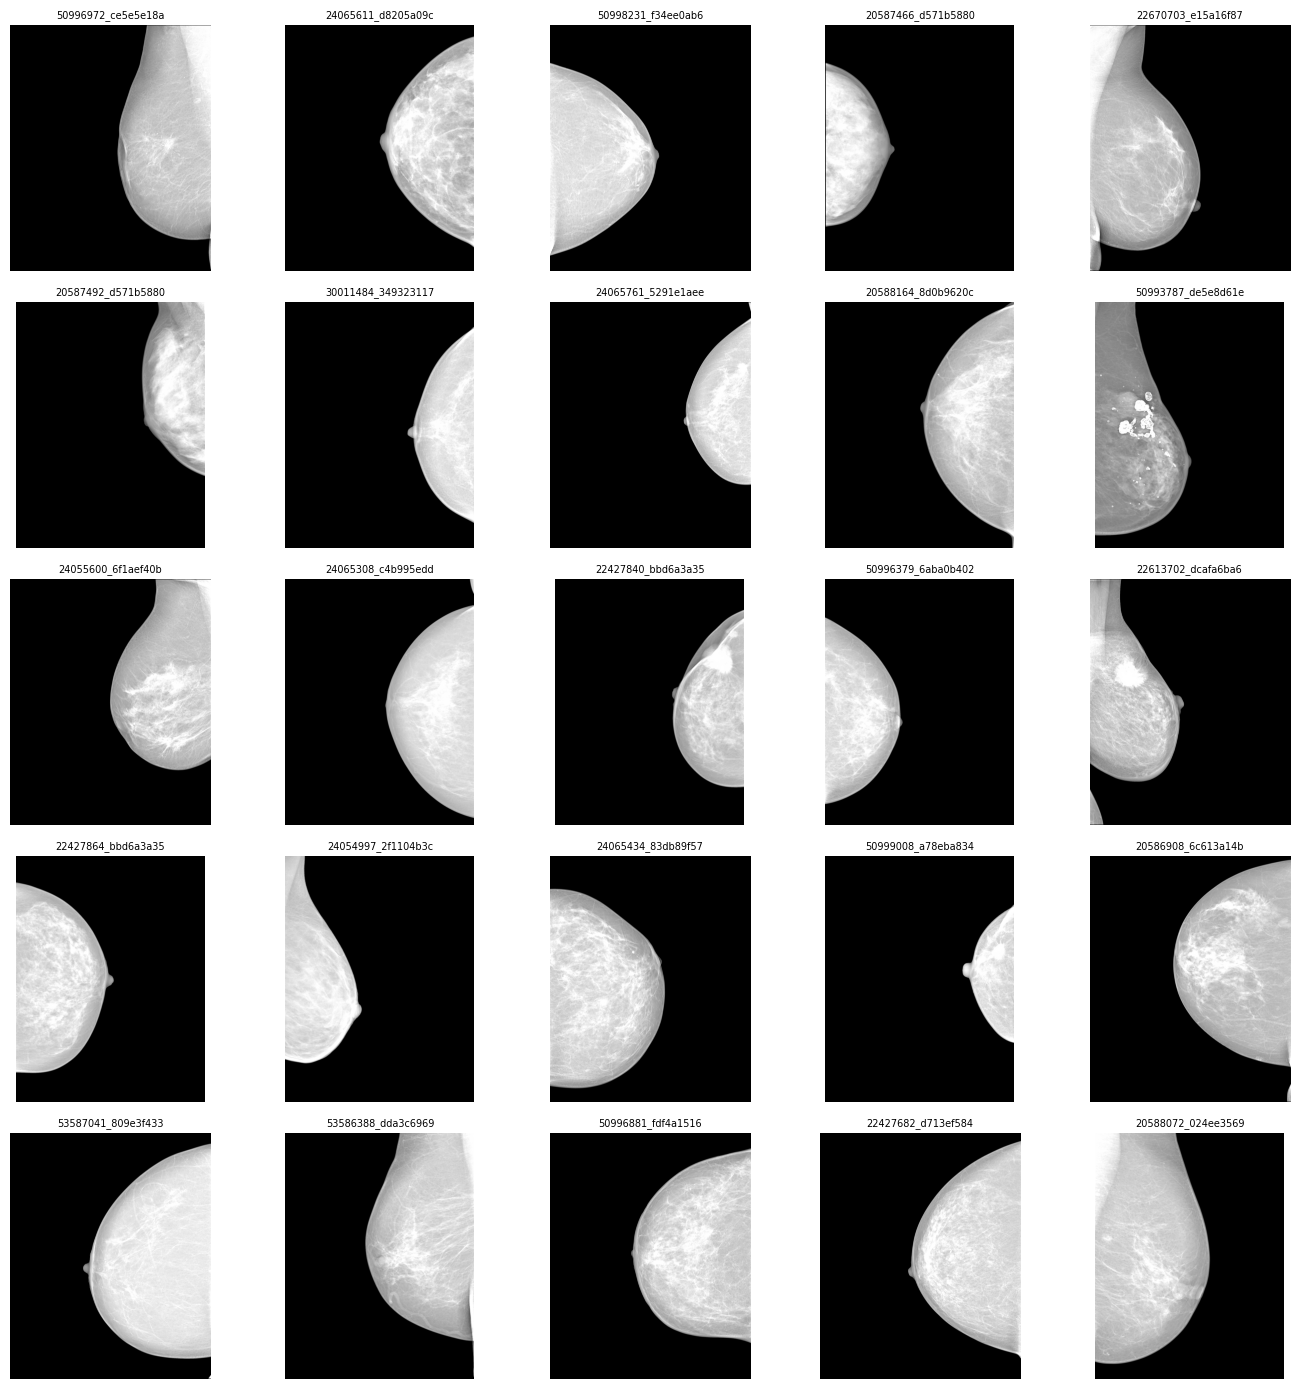

In [6]:
import random
from pathlib import Path

import numpy as np
import pydicom
import matplotlib.pyplot as plt

# ---- CONFIG ----
IMG_DIR = Path("../data/raw/inbreast/ALL-IMGS")
N = 25  # number of random images to show
SEED = 34  # fixed seed -> same 25 images every run (project-wide random_state)
FIGSIZE = (14, 14)  # overall figure size
# ----------------

def load_for_display(dicom_path: Path) -> np.ndarray:
    """Read an INbreast DICOM and return a [0, 1] float32 array.

    A 1st/99th-percentile clip is used instead of a raw min-max stretch:
    a few extreme pixels per image (markers, hot pixels) would otherwise
    dominate the rescaling and compress real breast tissue into a narrow
    band near zero.  All 410 INbreast files are MONOCHROME2 with no VOI
    LUT, so no inversion or windowing is needed.
    """
    ds = pydicom.dcmread(str(dicom_path))
    img = ds.pixel_array.astype(np.float32)

    # robust normalisation to [0, 1]
    lo, hi = np.percentile(img, (1, 99))
    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo + 1e-8)
    return img

dicoms = sorted(IMG_DIR.glob("*.dcm"))  # sorted so the seeded sample is reproducible
if not dicoms:
    raise FileNotFoundError(f"No .dcm files found in {IMG_DIR.resolve()}")

sample = random.Random(SEED).sample(dicoms, k=min(N, len(dicoms)))
print(f"Showing {len(sample)} random DICOMs from: {IMG_DIR.resolve()}")

plt.figure(figsize=FIGSIZE)

for i, p in enumerate(sample, 1):
    try:
        img = load_for_display(p)
        plt.subplot(5, 5, i)
        plt.imshow(img, cmap="gray")
        plt.title(p.name[:18], fontsize=7)
        plt.axis("off")
    except Exception as e:
        plt.subplot(5, 5, i)
        plt.text(0.5, 0.5, f"Error\n{p.name}\n{type(e).__name__}", ha="center", va="center", fontsize=7)
        plt.axis("off")

plt.tight_layout()
plt.show()

### What the visual survey tells us

Things I want to flag from the grid:

- **Two clear view types are visible.** CC views give a clean breast shape with no muscle. MLO (and ML) views show the breast at an angle with the pectoral muscle visible at the top-left or top-right corner (depending on laterality). The pectoral muscle is roughly as dense as fibroglandular tissue, so it would be mis-classified as breast tissue unless I mask it out.
- **Image dimensions vary noticeably.** Some breasts fill the field; others have large black backgrounds. A breast-mask + tight crop in Step 1.1 is needed before any patch-level analysis.
- **Density spans the full ACR range.** I can see uniformly-dark almost-entirely-fatty breasts and uniformly-bright extremely-dense ones in the same grid. That spread is encouraging for the fatty-vs-fibroglandular classification task — there is clearly visual signal to learn from.
